# Phase 1: Dataset Acquisition & Verification — xBD / xView2

## 1. Objective

Before any exploratory analysis or modeling begins, this notebook verifies the integrity and structure of the downloaded xBD dataset — confirming file counts match across `images/`, `labels/`, and `targets/`, and that damage labels are correctly aligned to their corresponding buildings in the imagery. This mirrors the verification discipline applied to the raw transaction data in the fraud-risk engine (Phase 1), adapted here for image/annotation data instead of tabular CSVs.

**Dataset source:** [xBD / xView2 Challenge](https://xview2.org/dataset) (CMU SEI & U.S. Defense Innovation Unit). Both the Challenge training set and test set archives were downloaded and SHA1-verified against official checksums prior to extraction.

## 2. What This Notebook Covers

1. Disaster type identification & image pre/post pair counts (`src/verify_dataset.py`)
2. Images / Labels / Targets parity verification, across both train and test splits
3. Disaster type selection for this project, with reasoning
4. Visual label-overlay verification: plotting damage polygons on top of real imagery to confirm alignment, sampled across all selected disaster types

## 3. Selected Disaster Types

- **Training:** `hurricane-harvey` (flood/wind damage) + `socal-fire` (fire damage) — chosen for being visually and mechanically distinct damage types
- **Held-out generalization test (Phase 7):** `mexico-earthquake` (structural collapse) — mechanically distinct from both training types, making it a genuine test of generalization
- **Excluded:** `guatemala-volcano` (only 18 pairs, too small to be useful)

Full verification results and reasoning are documented in `phase1_docs/data_verification_log.md`.

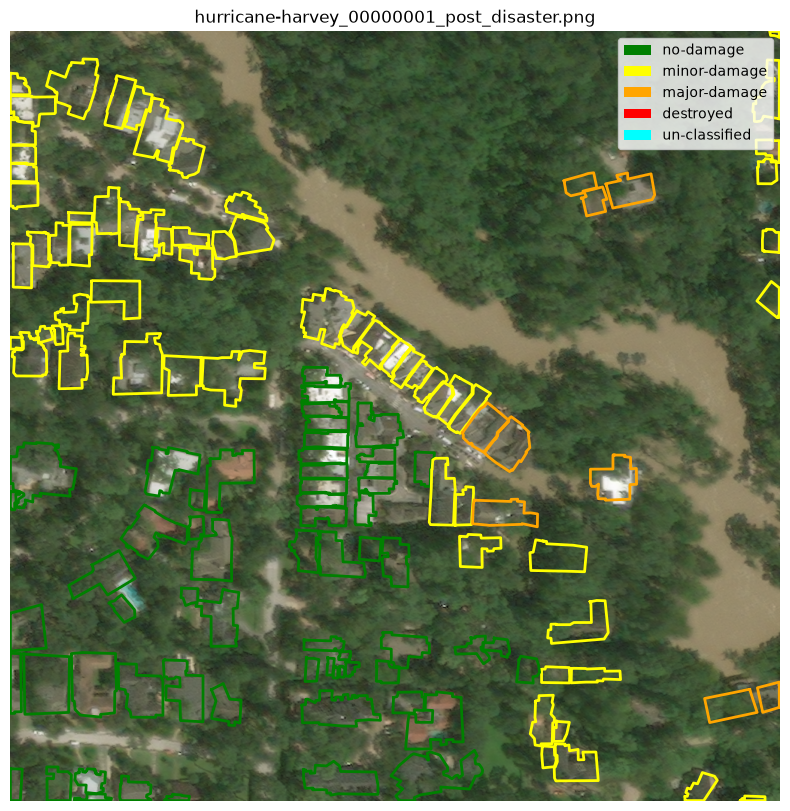

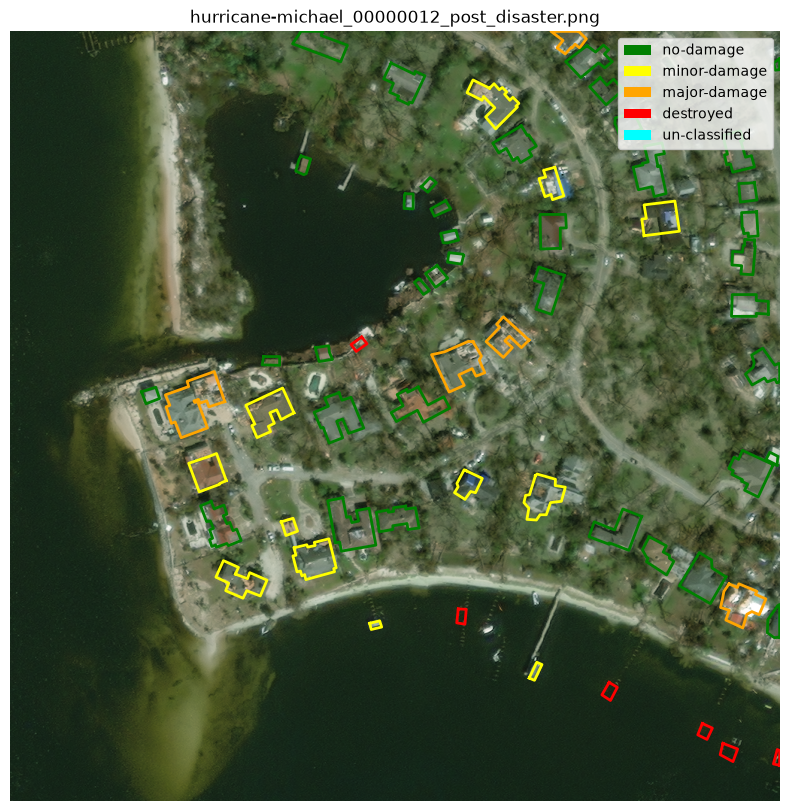

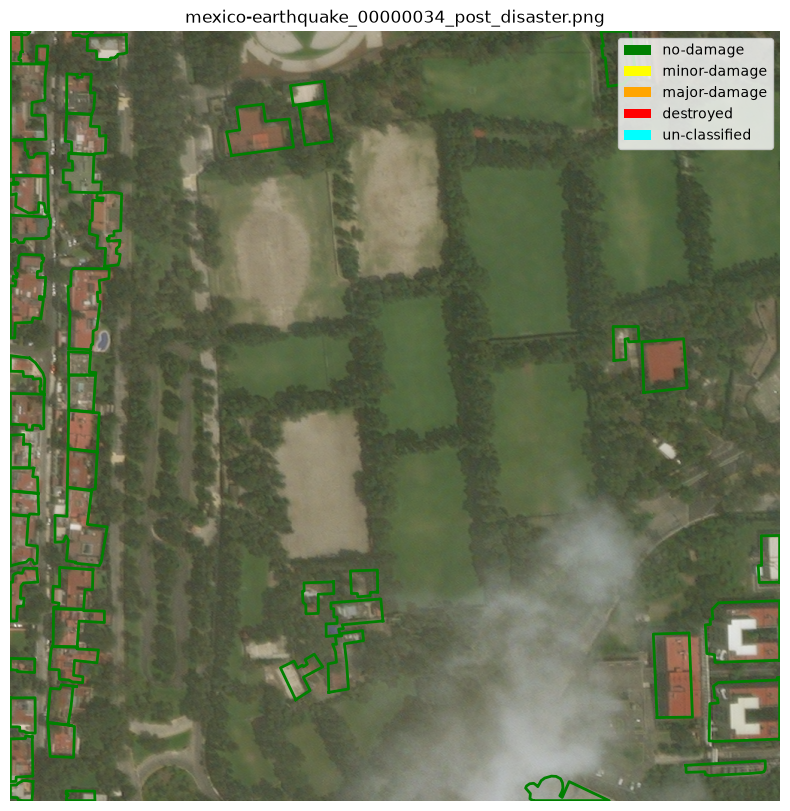

In [45]:
import json
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from shapely.wkt import loads as wkt_loads
import os

# Define standard xBD damage color mapping
DAMAGE_COLORS = {
    "no-damage": "green",
    "minor-damage": "yellow",
    "major-damage": "orange",
    "destroyed": "red",
    "un-classified": "cyan"
}

# File path for image
image_paths = [
       "../data/raw/train/images/hurricane-harvey_00000001_post_disaster.png",
       "../data/raw/train/images/hurricane-michael_00000012_post_disaster.png",
       "../data/raw/train/images/mexico-earthquake_00000034_post_disaster.png",
   ]
for image_path in image_paths:
    if not os.path.exists(image_path):
        print(f"Skipping missing file: {image_path}")
        continue
    
    img_array = plt.imread(image_path)

    # Replaces 'images' directory with 'labels' and '.png' with '.json'
    json_path = image_path.replace("images", "labels").replace(".png", ".json")

    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(img_array)

    # Open and load the JSON file
    with open(json_path, "r") as file:
        d = json.load(file)
    
        for building in d['features']['xy']:
            damage = building['properties'].get('subtype')
            uid = building['properties'].get('uid')
            wkt_str = building['wkt']
            polygon = wkt_loads(wkt_str)
            # Extract coordinate pairs ((x1, y1), (x2, y2), ...)
            coords = list(polygon.exterior.coords)
            xs, ys = zip(*coords)
            color = DAMAGE_COLORS.get(damage, "cyan")
            ax.plot(xs, ys, color=color, linewidth=2)
    
    ax.axis('off')
    ax.set_title(os.path.basename(image_path))
    legend_elements = [Patch(facecolor=color, label=label) for label, color in DAMAGE_COLORS.items()]
    ax.legend(handles=legend_elements, loc='upper right')
    plt.show()
    plt.close(fig)  # Free memory after displaying